In [1]:
import pandas as pd
import matplotlib.pyplot as plt

train = pd.read_csv("../data/raw/train.csv")

train["Date"] = pd.to_datetime(train["Date"])

# Use only open stores
open_sales = train[train["Open"] == 1]

# Aggregate sales across all stores by date
daily_sales = (
    open_sales
    .groupby("Date")["Sales"]
    .sum()
    .reset_index()
    .sort_values("Date")
)

daily_sales.head()

/var/folders/vk/6pn68sk92z93wvsph2msbyvh0000gn/T/ipykernel_21898/2228451799.py:4: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/raw/train.csv")


,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593


In [2]:
print("Start Date:", daily_sales["Date"].min())
print("End Date:", daily_sales["Date"].max())
print("Number of observations:", len(daily_sales))

Start Date: 2013-01-01 00:00:00
End Date: 2015-07-31 00:00:00
Number of observations: 942


In [3]:
date_range = pd.date_range(
    start=daily_sales["Date"].min(),
    end=daily_sales["Date"].max(),
    freq="D"
)

missing_dates = date_range.difference(daily_sales["Date"])

print("Missing dates:", len(missing_dates))

Missing dates: 0


In [4]:
# Use the last 30 days as the test set
test_size = 30

train_data = daily_sales.iloc[:-test_size].copy()
test_data = daily_sales.iloc[-test_size:].copy()

print("Training period:")
print(train_data["Date"].min(), "to", train_data["Date"].max())

print("\nTesting period:")
print(test_data["Date"].min(), "to", test_data["Date"].max())

print("\nTraining observations:", len(train_data))
print("Testing observations:", len(test_data))

Training period:
2013-01-01 00:00:00 to 2015-07-01 00:00:00

Testing period:
2015-07-02 00:00:00 to 2015-07-31 00:00:00

Training observations: 912
Testing observations: 30


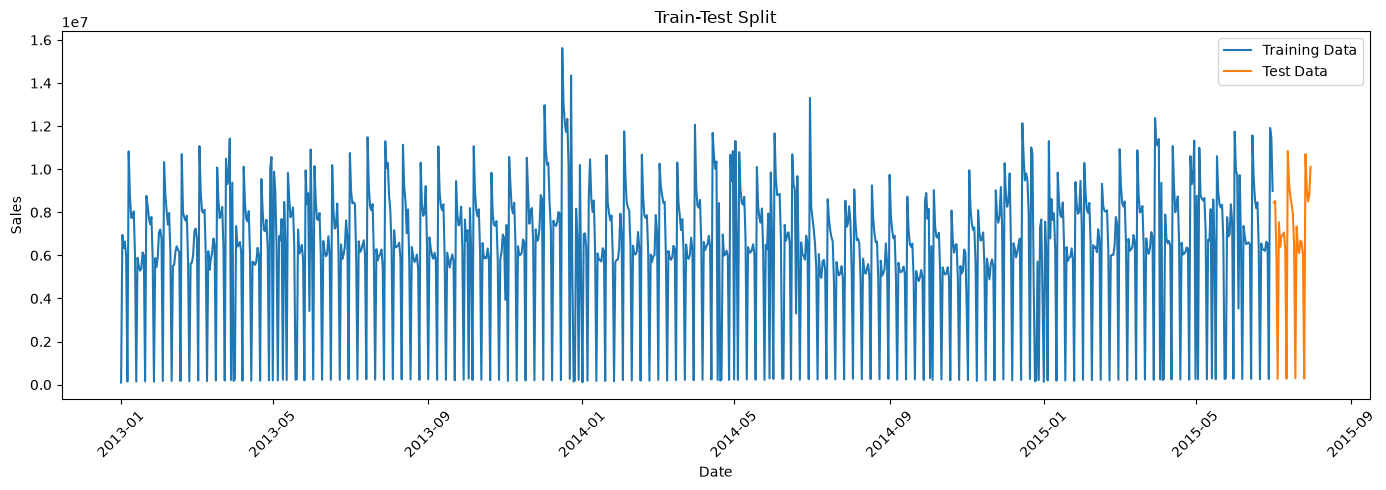

In [5]:
plt.figure(figsize=(14, 5))

plt.plot(
    train_data["Date"],
    train_data["Sales"],
    label="Training Data"
)

plt.plot(
    test_data["Date"],
    test_data["Sales"],
    label="Test Data"
)

plt.title("Train-Test Split")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

In [6]:
daily_sales

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593
...,...,...
937,2015-07-27,10707292
938,2015-07-28,9115073
939,2015-07-29,8499962
940,2015-07-30,8798854


In [7]:
train = daily_sales.iloc[:-30]

In [8]:
daily_sales.iloc[0:100]

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593
...,...,...
95,2013-04-06,6171054
96,2013-04-07,189097
97,2013-04-08,10115602
98,2013-04-09,8418477


In [9]:
daily_sales.iloc[:-30]

,Date,Sales
0,2013-01-01,97235
1,2013-01-02,6949829
2,2013-01-03,6347820
3,2013-01-04,6638954
4,2013-01-05,5951593
...,...,...
907,2015-06-27,6538314
908,2015-06-28,262669
909,2015-06-29,11916672
910,2015-06-30,11483932


In [10]:
test = daily_sales.iloc[-30:]

In [11]:
train = daily_sales.iloc[:-30].copy()
test = daily_sales.iloc[-30:].copy()

In [12]:
# Naive Forecast
last_train_value = train["Sales"].iloc[-1]

test["Naive_Forecast"] = last_train_value

test.head()

,Date,Sales,Naive_Forecast
912,2015-07-02,8446293,8989672
913,2015-07-03,8530388,8989672
914,2015-07-04,6054276,8989672
915,2015-07-05,269248,8989672
916,2015-07-06,7540473,8989672


In [13]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(
    test["Sales"],
    test["Naive_Forecast"]
)

rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        test["Naive_Forecast"]
    )
)

mape = np.mean(
    np.abs(
        (test["Sales"] - test["Naive_Forecast"])
        / test["Sales"]
    )
) * 100

print("Naive Forecast Performance")
print("---------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

Naive Forecast Performance
---------------------------
MAE  : 2,556,268.47
RMSE : 3,626,993.83
MAPE : 431.40%


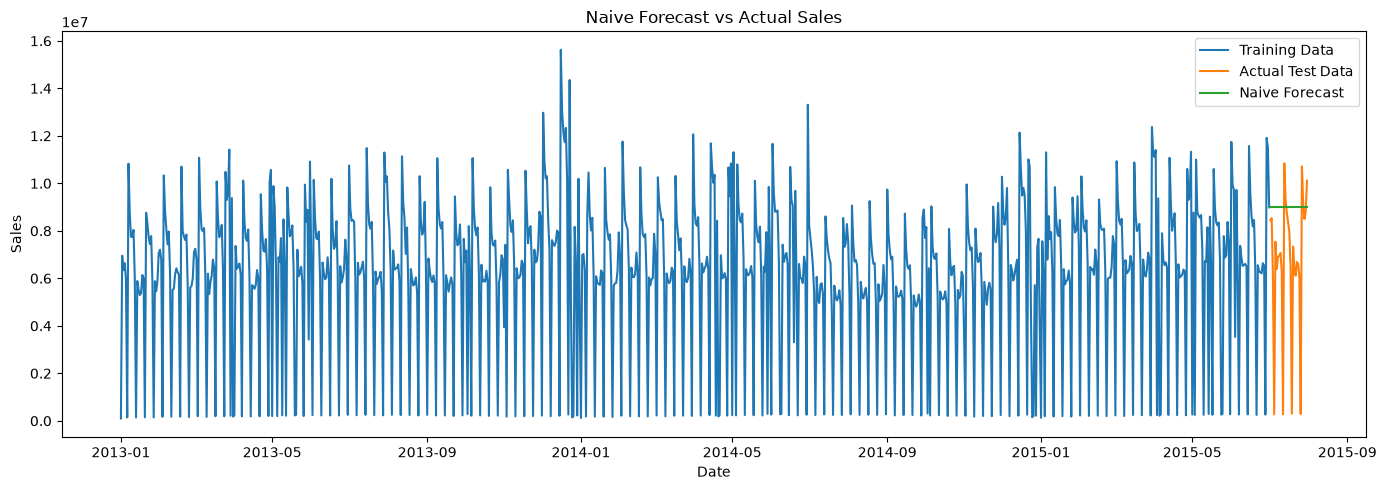

In [14]:
plt.figure(figsize=(14, 5))

plt.plot(
    train["Date"],
    train["Sales"],
    label="Training Data"
)

plt.plot(
    test["Date"],
    test["Sales"],
    label="Actual Test Data"
)

plt.plot(
    test["Date"],
    test["Naive_Forecast"],
    label="Naive Forecast"
)

plt.title("Naive Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()
plt.show()

In [15]:
from statsmodels.tsa.stattools import adfuller

# Training sales as a time series
train_ts = train.set_index("Date")["Sales"]

# Perform Augmented Dickey-Fuller test
adf_result = adfuller(train_ts)

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])

ADF Statistic: -4.724227216102522
p-value: 7.576260754328197e-05


In [16]:
# Seasonal Naive Forecast using a 7-day seasonal period

seasonal_period = 7

test["Seasonal_Naive_Forecast"] = (
    train_data["Sales"]
    .iloc[-seasonal_period:]
    .tolist()
    * (len(test_data) // seasonal_period + 1)
)[:len(test_data)]

test.head(10)

,Date,Sales,Naive_Forecast,Seasonal_Naive_Forecast
912,2015-07-02,8446293,8989672,6211764
913,2015-07-03,8530388,8989672,6634687
914,2015-07-04,6054276,8989672,6538314
915,2015-07-05,269248,8989672,262669
916,2015-07-06,7540473,8989672,11916672
917,2015-07-07,6393024,8989672,11483932
918,2015-07-08,6915625,8989672,8989672
919,2015-07-09,6938182,8989672,6211764
920,2015-07-10,7064909,8989672,6634687
921,2015-07-11,6262022,8989672,6538314


In [17]:
# Repeat the last 7 training days across the 30-day test period

last_7_days = train_data["Sales"].iloc[-7:].values

test_data["Seasonal_Naive_Forecast"] = [
    last_7_days[i % 7]
    for i in range(len(test_data))
]

test_data.head(10)

,Date,Sales,Seasonal_Naive_Forecast
912,2015-07-02,8446293,6211764
913,2015-07-03,8530388,6634687
914,2015-07-04,6054276,6538314
915,2015-07-05,269248,262669
916,2015-07-06,7540473,11916672
917,2015-07-07,6393024,11483932
918,2015-07-08,6915625,8989672
919,2015-07-09,6938182,6211764
920,2015-07-10,7064909,6634687
921,2015-07-11,6262022,6538314


In [18]:
test_data[["Date", "Sales", "Seasonal_Naive_Forecast"]].head(10)

,Date,Sales,Seasonal_Naive_Forecast
912,2015-07-02,8446293,6211764
913,2015-07-03,8530388,6634687
914,2015-07-04,6054276,6538314
915,2015-07-05,269248,262669
916,2015-07-06,7540473,11916672
917,2015-07-07,6393024,11483932
918,2015-07-08,6915625,8989672
919,2015-07-09,6938182,6211764
920,2015-07-10,7064909,6634687
921,2015-07-11,6262022,6538314


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

actual = test_data["Sales"]
forecast = test_data["Seasonal_Naive_Forecast"]

mae = mean_absolute_error(actual, forecast)
rmse = np.sqrt(mean_squared_error(actual, forecast))

# Avoid division by zero in MAPE
mape = np.mean(
    np.abs((actual - forecast) / actual.replace(0, np.nan))
) * 100

print("Seasonal Naive Forecast Performance")
print("-----------------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

Seasonal Naive Forecast Performance
-----------------------------------
MAE  : 1,614,210.23
RMSE : 2,260,598.83
MAPE : 22.18%


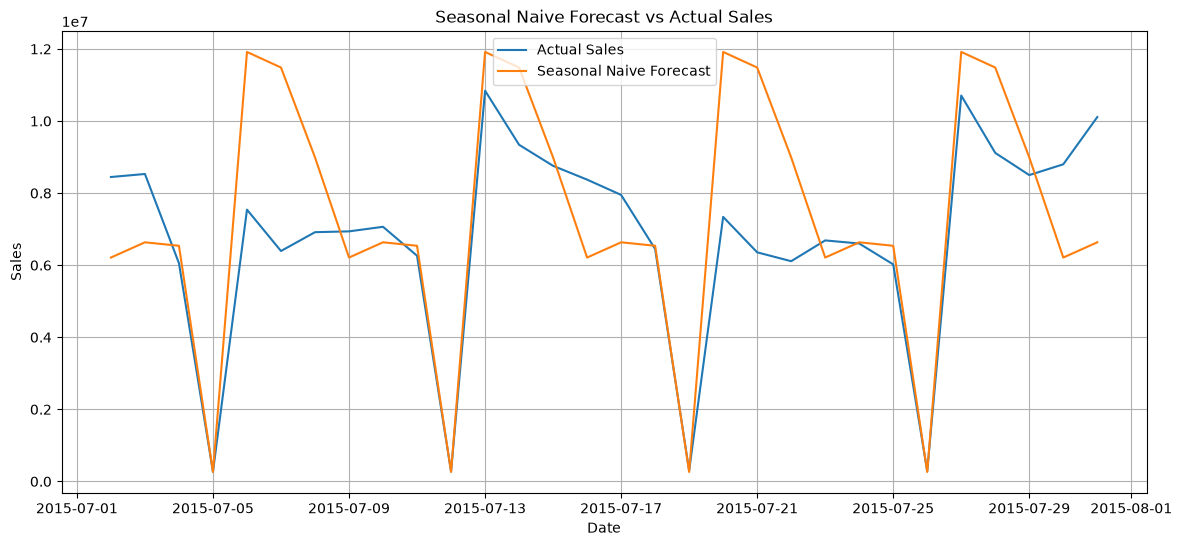

In [20]:
plt.figure(figsize=(14, 6))

plt.plot(
    test_data["Date"],
    test_data["Sales"],
    label="Actual Sales"
)

plt.plot(
    test_data["Date"],
    test_data["Seasonal_Naive_Forecast"],
    label="Seasonal Naive Forecast"
)

plt.title("Seasonal Naive Forecast vs Actual Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [21]:
# Create a copy of the training data
ml_data = train.copy()

# Create lag features
ml_data["Lag_1"] = ml_data["Sales"].shift(1)
ml_data["Lag_7"] = ml_data["Sales"].shift(7)
ml_data["Lag_14"] = ml_data["Sales"].shift(14)

# Remove rows with missing lag values
ml_data = ml_data.dropna()

ml_data.head()

,Date,Sales,Lag_1,Lag_7,Lag_14
14,2013-01-15,5512591,5886788.0,8749437.0,97235.0
15,2013-01-16,5293020,5512591.0,7746603.0,6949829.0
16,2013-01-17,5386564,5293020.0,7751485.0,6347820.0
17,2013-01-18,6137010,5386564.0,8039306.0,6638954.0
18,2013-01-19,6010192,6137010.0,6017491.0,5951593.0


In [22]:
# Create calendar features

ml_data["DayOfWeek"] = ml_data["Date"].dt.dayofweek
ml_data["Month"] = ml_data["Date"].dt.month
ml_data["Year"] = ml_data["Date"].dt.year

ml_data.head()

,Date,Sales,Lag_1,Lag_7,Lag_14,DayOfWeek,Month,Year
14,2013-01-15,5512591,5886788.0,8749437.0,97235.0,1,1,2013
15,2013-01-16,5293020,5512591.0,7746603.0,6949829.0,2,1,2013
16,2013-01-17,5386564,5293020.0,7751485.0,6347820.0,3,1,2013
17,2013-01-18,6137010,5386564.0,8039306.0,6638954.0,4,1,2013
18,2013-01-19,6010192,6137010.0,6017491.0,5951593.0,5,1,2013


In [23]:
# Create rolling average features

ml_data["Rolling_7_Day"] = ml_data["Sales"].shift(1).rolling(7).mean()
ml_data["Rolling_14_Day"] = ml_data["Sales"].shift(1).rolling(14).mean()

# Remove rows with missing values
ml_data = ml_data.dropna()

ml_data.head()

,Date,Sales,Lag_1,Lag_7,Lag_14,DayOfWeek,Month,Year,Rolling_7_Day,Rolling_14_Day
28,2013-01-29,5452668,5878702.0,8320289.0,5512591.0,1,1,2013,6.165400e+06,5.743561e+06
29,2013-01-30,5909779,5452668.0,7746563.0,5293020.0,2,1,2013,5.755739e+06,5.739280e+06
30,2013-01-31,7068567,5909779.0,7439836.0,5386564.0,3,1,2013,5.493342e+06,5.783335e+06
31,2013-02-01,7203007,7068567.0,7780789.0,6137010.0,4,2,2013,5.440303e+06,5.903478e+06
32,2013-02-02,6781741,7203007.0,5848770.0,6010192.0,5,2,2013,5.357763e+06,5.979620e+06


In [24]:
# Features
features = [
    "Lag_1",
    "Lag_7",
    "Lag_14",
    "DayOfWeek",
    "Month",
    "Year",
    "Rolling_7_Day",
    "Rolling_14_Day"
]

X = ml_data[features]
y = ml_data["Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (884, 8)
Target shape: (884,)


In [25]:
split = int(len(ml_data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 707
Testing samples: 177


In [26]:
from sklearn.ensemble import RandomForestRegressor

# Create the model
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [31]:
# Predict sales for the test data
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[7992289.49  5722358.66  8929670.36  6879445.71  6118856.635  199742.45
 4854742.045 8523829.225 8477257.245 6693561.18 ]


In [32]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print("Random Forest Performance")
print("-------------------------")
print(f"MAE  : {mae:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"MAPE : {mape:.2f}%")

Random Forest Performance
-------------------------
MAE  : 788,853.02
RMSE : 1,550,665.98
MAPE : 78.90%


In [34]:
results = pd.DataFrame({
    "Sales": y_test.values,
    "Predicted_Sales": y_pred
})

results.head(10)

,Sales,Predicted_Sales
0,6791481,7992289.490
1,8621857,5722358.660
2,7646645,8929670.360
3,7945387,6879445.710
4,6277742,6118856.635
5,183367,199742.450
6,9840664,4854742.045
7,8538569,8523829.225
8,7881690,8477257.245
9,7774935,6693561.180


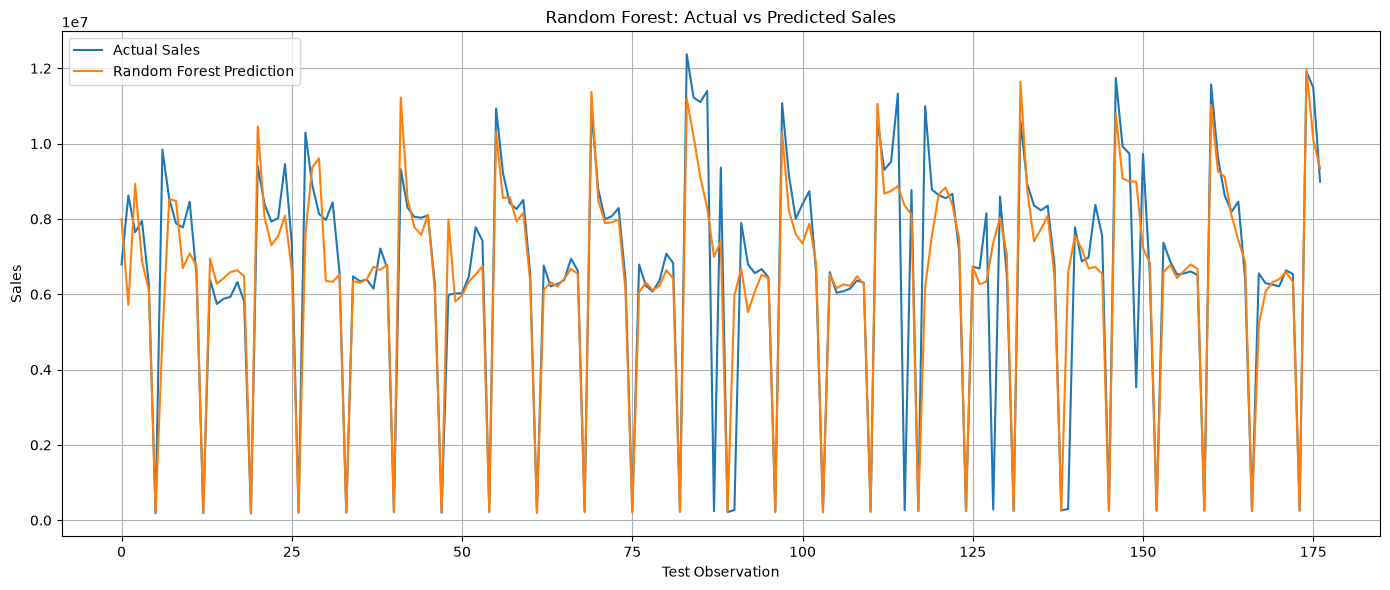

In [35]:
plt.figure(figsize=(14, 6))

plt.plot(
    y_test.values,
    label="Actual Sales"
)

plt.plot(
    y_pred,
    label="Random Forest Prediction"
)

plt.title("Random Forest: Actual vs Predicted Sales")
plt.xlabel("Test Observation")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [36]:
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)

print("R² Score:", r2)

R² Score: 0.7678263928948822


In [37]:
import pandas as pd
import matplotlib.pyplot as plt

importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(importance)

DayOfWeek         0.630403
Lag_14            0.108893
Lag_1             0.098161
Lag_7             0.065129
Rolling_14_Day    0.039876
Rolling_7_Day     0.039537
Month             0.015274
Year              0.002727
dtype: float64


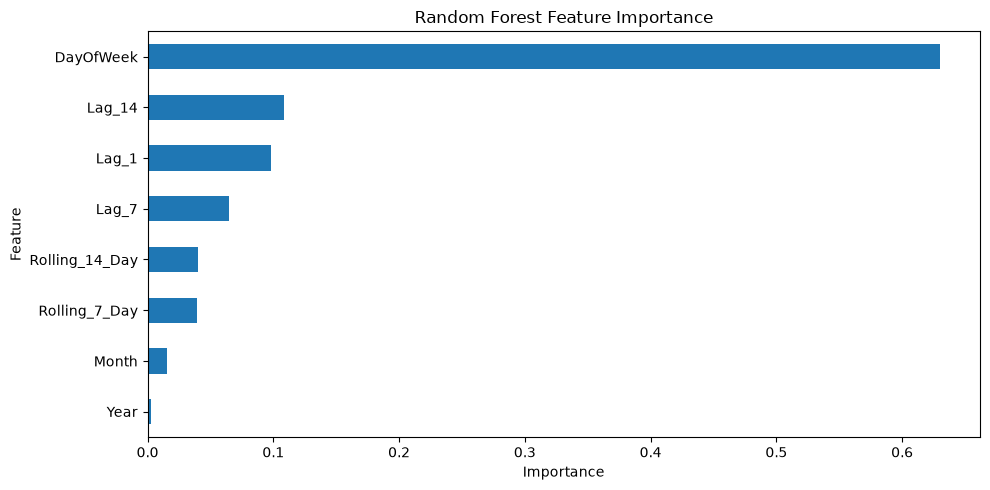

In [38]:
plt.figure(figsize=(10, 5))

importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [39]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Forecast",
        "Seasonal Naive",
        "Random Forest"
    ],
    "MAE": [
        2556268.47,
        1614210.23,
        788853.02
    ],
    "RMSE": [
        3626993.83,
        2260598.83,
        1550665.98
    ],
    "MAPE": [
        431.40,
        22.18,
        78.90
    ],
    "R2": [
        np.nan,
        np.nan,
        0.7678
    ]
})

comparison

,Model,MAE,RMSE,MAPE,R2
0,Naive Forecast,2556268.47,3626993.83,431.40,NaN
1,Seasonal Naive,1614210.23,2260598.83,22.18,NaN
2,Random Forest,788853.02,1550665.98,78.90,0.7678
